# Shot chart — Βασσάκης, Νικόλαος (player 302)
Match: Clicka BC vs Unleash the Clowns — 09/06/2026 (Playoff, League 1)

Source: `data/raw/teams/unleash-the-clowns/match.html`

In [27]:
from pathlib import Path
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import urllib.request

HTML_PATH = Path("../data/raw/teams/unleash-the-clowns/match.html")
PLAYER_ID = "302"  # Βασσάκης , Νικόλαος

In [28]:
with open(HTML_PATH, encoding="utf-8") as f:
    soup = BeautifulSoup(f, "lxml")

shots = []
for g in soup.select(f'g[data-user="{PLAYER_ID}"]'):
    circle = g.find("circle")
    stat = g["data-stat"]
    shots.append({
        "period": int(g["data-period"]) + 1,
        "shot_type": "2PT" if stat.startswith("2") else "3PT",
        "made": stat.endswith("S"),
        "x": int(circle["cx"]),
        "y": int(circle["cy"]),
    })

shots_df = pd.DataFrame(shots)
shots_df

,period,shot_type,made,x,y
0,1,2PT,True,912,288
1,2,2PT,False,910,238
2,3,2PT,True,931,252
3,2,3PT,False,880,477
4,2,3PT,False,833,48
5,2,3PT,False,821,78
6,2,3PT,True,721,214
7,2,3PT,False,812,55


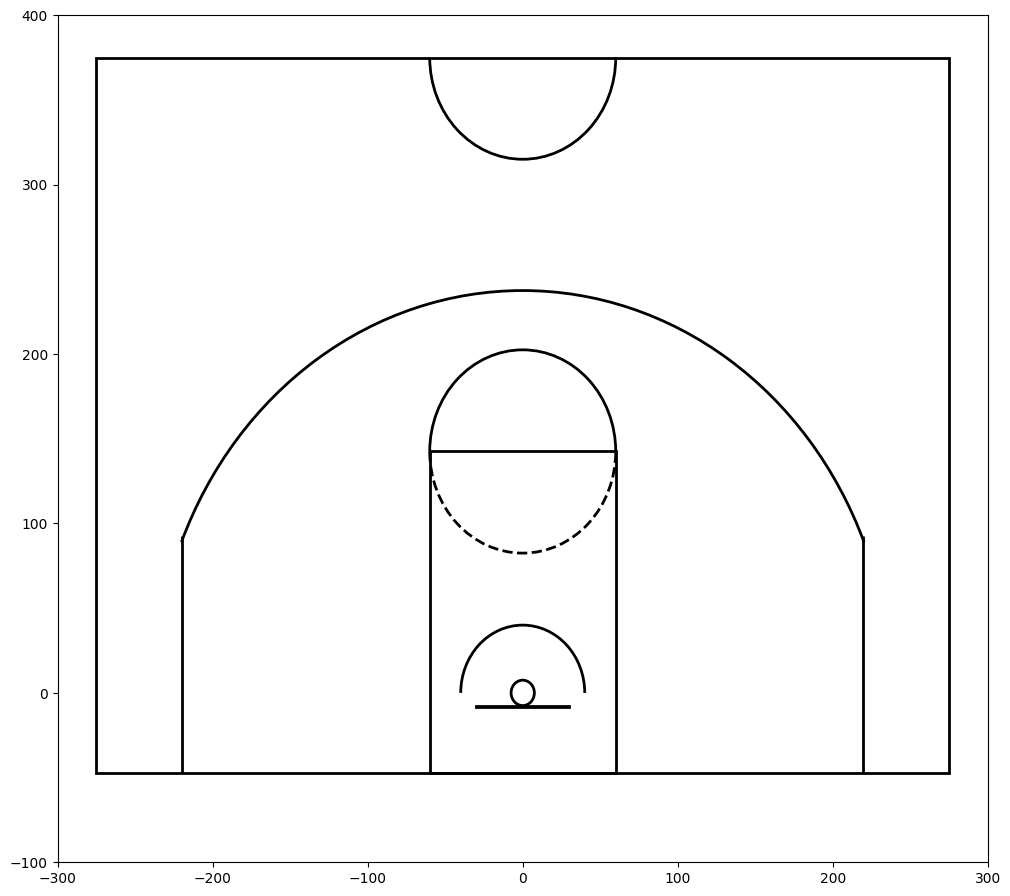

In [88]:
from matplotlib.patches import Circle, Rectangle, Arc

def draw_court(ax=None, color='black', lw=2, outer_lines=False):
    # If an axes object isn't provided to plot onto, just get current one
    if ax is None:
        ax = plt.gca()

    # Create the various parts of an NBA basketball court

    # Create the basketball hoop
    # Diameter of a hoop is 18" so it has a radius of 9", which is a value
    # 7.5 in our coordinate system
    hoop = Circle((0, 0), radius=7.5, linewidth=lw, color=color, fill=False)

    # Create backboard
    backboard = Rectangle((-30, -7.5), 60, -1, linewidth=lw, color=color)

    # The paint
    # Create the outer box 0f the paint, width=16ft, height=19ft
    outer_box = Rectangle((-80, -47.5), 160, 190, linewidth=lw, color=color,
                          fill=False)
    # Create the inner box of the paint, widt=12ft, height=19ft
    inner_box = Rectangle((-60, -47.5), 120, 190, linewidth=lw, color=color,
                          fill=False)

    # Create free throw top arc
    top_free_throw = Arc((0, 142.5), 120, 120, theta1=0, theta2=180,
                         linewidth=lw, color=color, fill=False)
    # Create free throw bottom arc
    bottom_free_throw = Arc((0, 142.5), 120, 120, theta1=180, theta2=0,
                            linewidth=lw, color=color, linestyle='dashed')
    # Restricted Zone, it is an arc with 4ft radius from center of the hoop
    restricted = Arc((0, 0), 80, 80, theta1=0, theta2=180, linewidth=lw,
                     color=color)

    # Three point line
    # Create the side 3pt lines, they are 14ft long before they begin to arc
    corner_three_a = Rectangle((-220, -47.5), 0, 140, linewidth=lw,
                               color=color)
    corner_three_b = Rectangle((219.5, -47.5), 0, 140, linewidth=lw, color=color)
    # 3pt arc - center of arc will be the hoop, arc is 23'9" away from hoop
    # I just played around with the theta values until they lined up with the 
    # threes
    three_arc = Arc((0, 0), 475, 475, theta1=22, theta2=158, linewidth=lw,
                    color=color)

    # Center Court
    center_outer_arc = Arc((0, 375), 120, 120, theta1=180, theta2=0,
                           linewidth=lw, color=color)
    center_inner_arc = Arc((0, 422.5), 40, 40, theta1=180, theta2=0,
                           linewidth=lw, color=color)

    # List of the court elements to be plotted onto the axes
    court_elements = [hoop, backboard, inner_box, top_free_throw,
                      bottom_free_throw, restricted, corner_three_a,
                      corner_three_b, three_arc, center_outer_arc]

    if outer_lines:
        # Draw the half court line, baseline and side out bound lines
        outer_lines = Rectangle((-275, -47.5), 550, 422.5, linewidth=lw,
                                color=color, fill=False)
        court_elements.append(outer_lines)

    # Add the court elements onto the axes
    for element in court_elements:
        ax.add_patch(element)

    return ax



plt.figure(figsize=(12,11))
draw_court(outer_lines=True)
plt.xlim(-300,300)
plt.ylim(-100,400)
plt.show()



In [89]:
HOOP_X, HOOP_Y = 944, 250
SCALE = 1.16

shots_df["court_x"] = (HOOP_Y - shots_df["y"]) * SCALE   # negate to fix left-right; flip back if needed
shots_df["court_y"] = (HOOP_X - shots_df["x"]) * SCALE


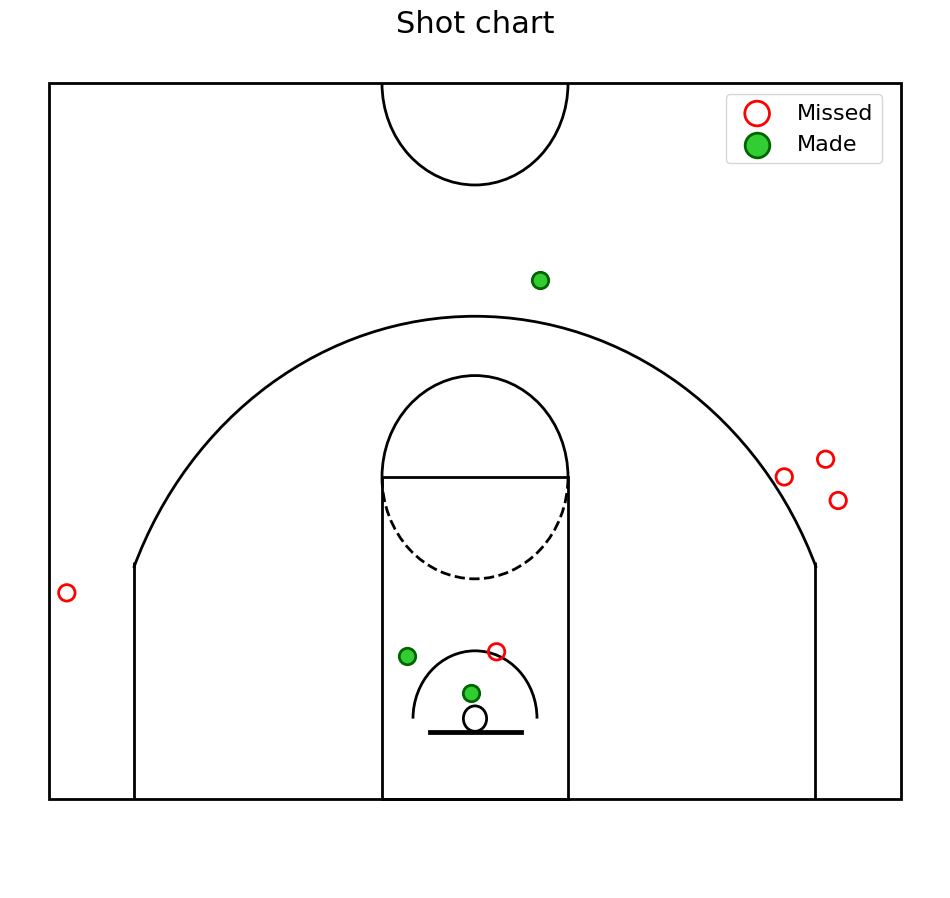

In [93]:
fig, ax = plt.subplots(figsize=(12, 11))
draw_court(ax, outer_lines=True)

made = shots_df[shots_df["made"]]
missed = shots_df[~shots_df["made"]]

ax.scatter(missed["court_x"], missed["court_y"], facecolors="none", edgecolors="red",
           s=140, linewidths=2, label="Missed")
ax.scatter(made["court_x"], made["court_y"], facecolors="limegreen", edgecolors="darkgreen",
           s=140, linewidths=2, label="Made")

ax.set_xlim(-300, 300)
ax.set_ylim(-100, 400)
ax.set_title("Shot chart")
ax.set_title("Shot chart", fontsize=22)
ax.legend(loc="upper right", bbox_to_anchor=(0.95, 0.95), fontsize=16, markerscale=1.5)
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
plt.show()


# Time to iterate to the whole away team

In [94]:
away_players = {}
for label in soup.select("label.player-check.away"):
    pid = label.find("input")["id"].replace("player-", "")
    name = label.find_parent("div", class_="player-name").get_text(strip=True)
    away_players[pid] = name

away_players


{'68': 'Ζέρβας, Παναγιώτης',
 '266': 'Glynos, Pavlos',
 '270': 'Χαλκίτης, Ηλίας',
 '297': 'Βαμβακαρης, Φραγκισκος',
 '302': 'Βασσάκης , Νικόλαος',
 '696': 'Sourgias, Panagiotis',
 '943': 'Παπαδατος, Σπυριδων Γρηγοριος'}

In [95]:
def get_shots(soup, player_id):
    shots = []
    for g in soup.select(f'g[data-user="{player_id}"]'):
        circle = g.find("circle")
        stat = g["data-stat"]
        shots.append({
            "period": int(g["data-period"]) + 1,
            "shot_type": "2PT" if stat.startswith("2") else "3PT",
            "made": stat.endswith("S"),
            "x": int(circle["cx"]),
            "y": int(circle["cy"]),
        })
    return pd.DataFrame(shots)


In [102]:
def plot_shot_chart(df, player_name, hoop_x=HOOP_X, hoop_y=HOOP_Y, scale_x=1.16, scale_y=1.16):
    df = df.copy()
    df["court_x"] = (hoop_y - df["y"]) * scale_x
    df["court_y"] = (hoop_x - df["x"]) * scale_y

    fig, ax = plt.subplots(figsize=(12, 11))
    draw_court(ax, outer_lines=True)

    made = df[df["made"]]
    missed = df[~df["made"]]

    ax.scatter(missed["court_x"], missed["court_y"], facecolors="none", edgecolors="red",
               s=140, linewidths=2, label="Missed")
    ax.scatter(made["court_x"], made["court_y"], facecolors="limegreen", edgecolors="darkgreen",
               s=140, linewidths=2, label="Made")

    ax.set_xlim(-300, 300)
    ax.set_ylim(-100, 400)
    ax.set_title(f"Shot chart - {player_name}", fontsize=22, fontweight="bold")
    ax.legend(loc="upper right", bbox_to_anchor=(0.95, 0.95), fontsize=16, markerscale=1.5)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    plt.show()


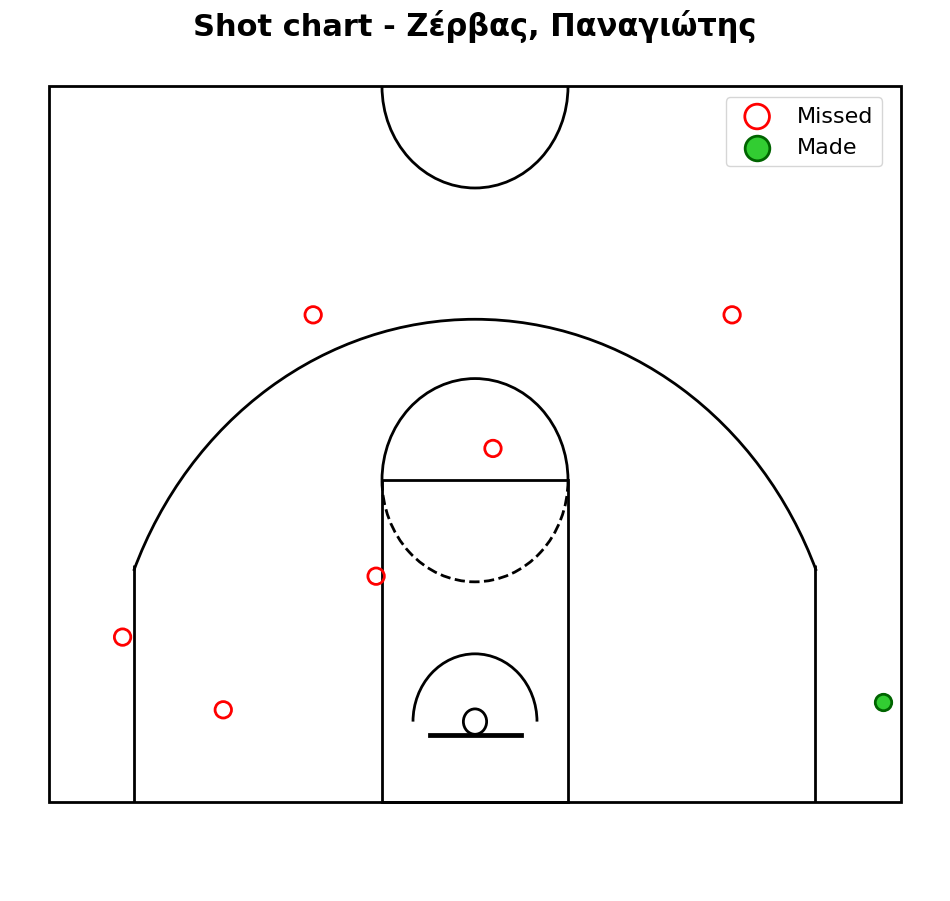

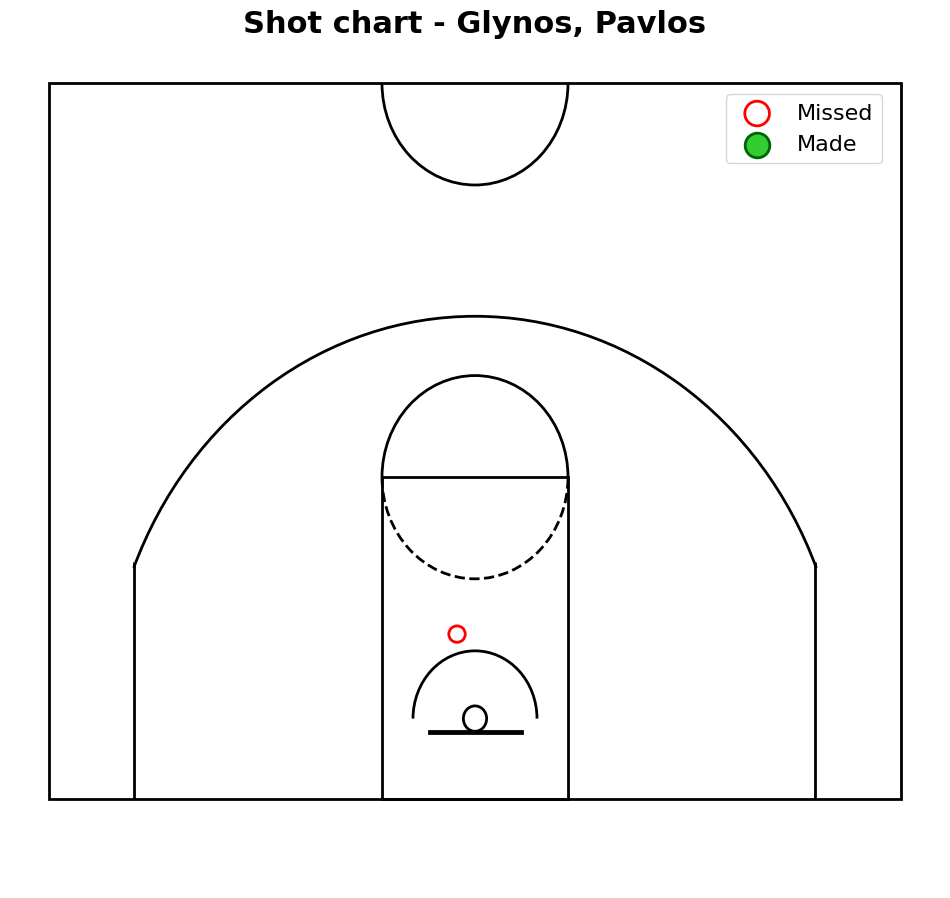

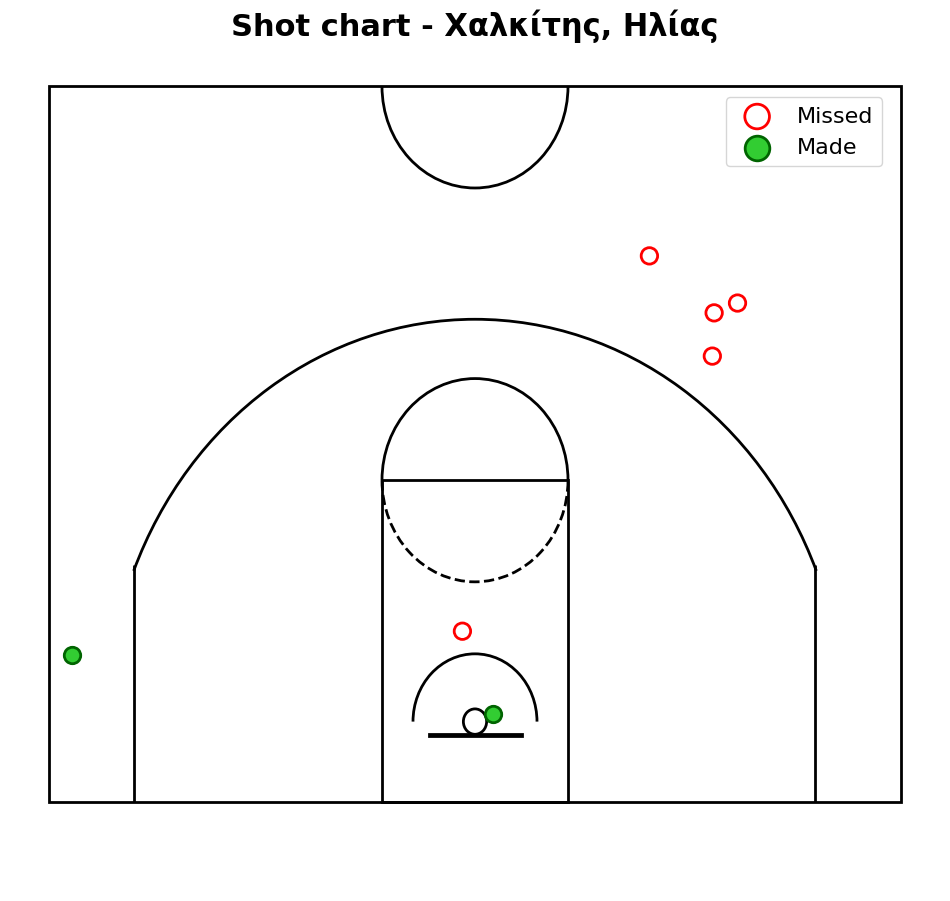

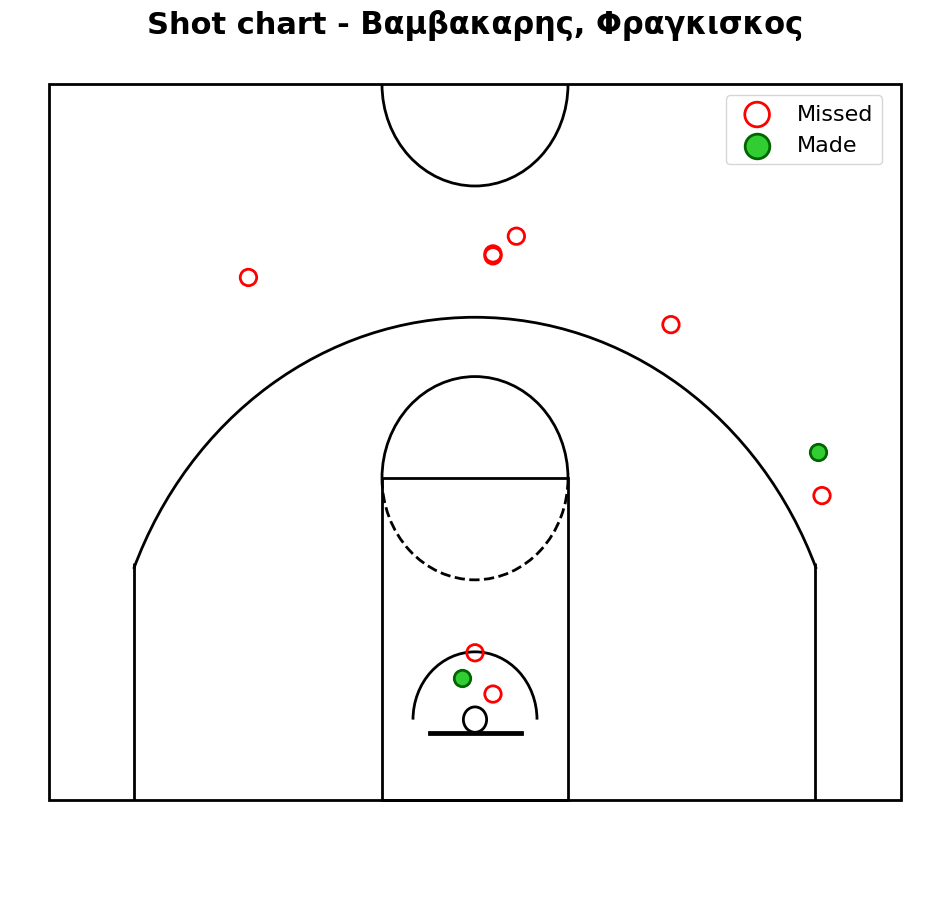

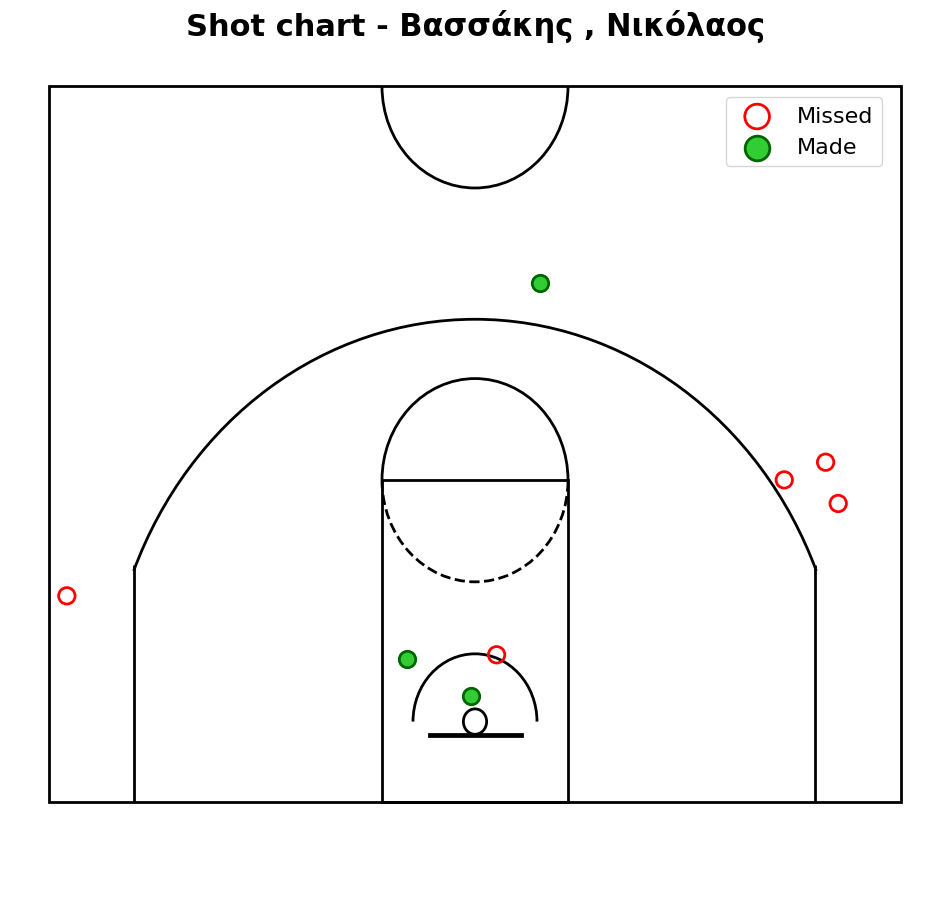

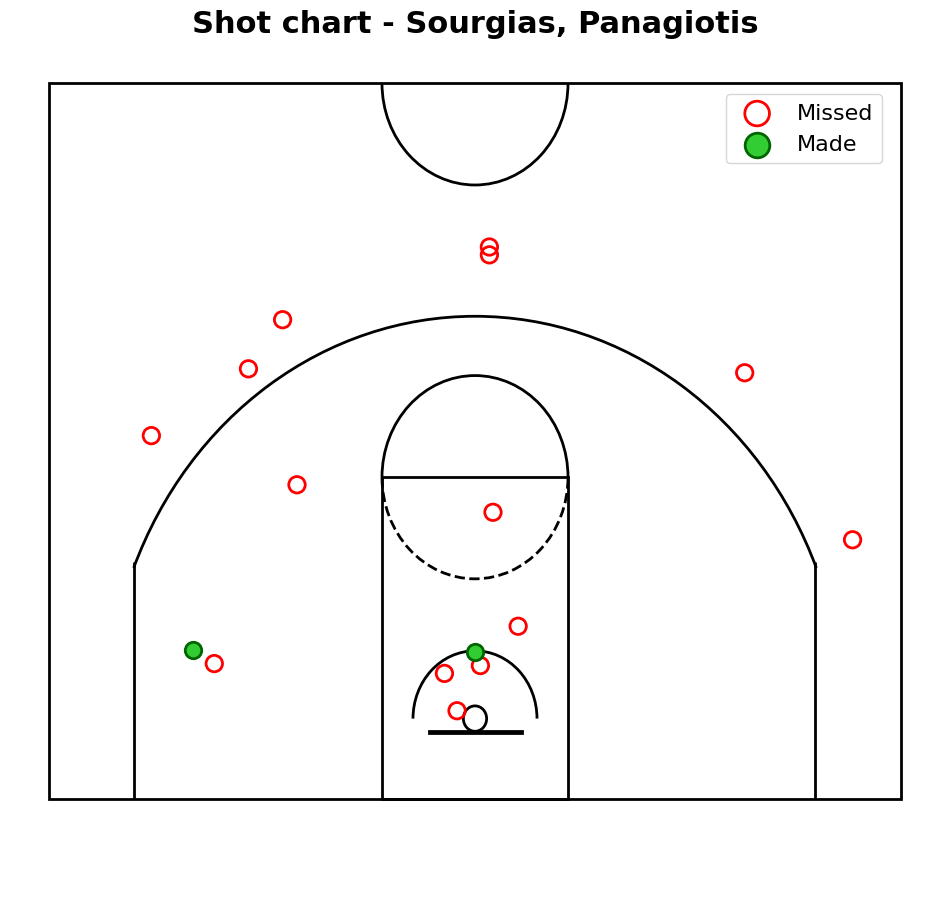

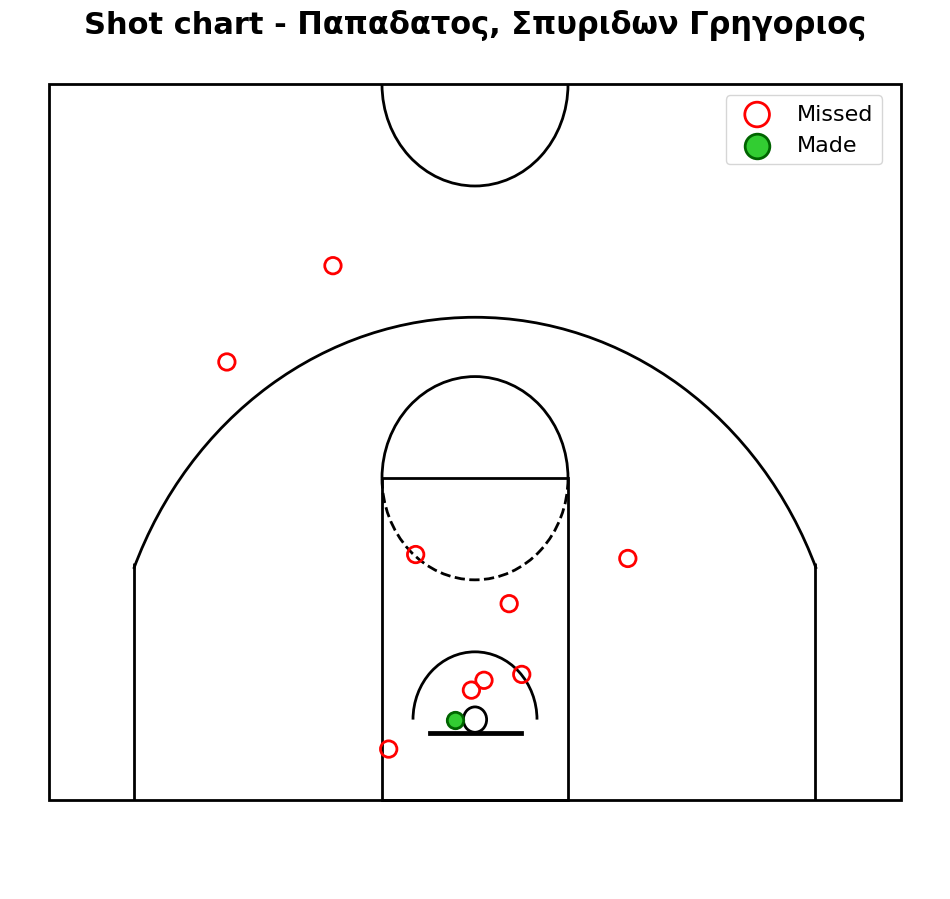

In [103]:
for pid, name in away_players.items():
    df = get_shots(soup, pid)
    if df.empty:
        continue
    plot_shot_chart(df, name)

# Get shot charts from both teams

In [105]:
def get_roster(soup, team):
    players = {}
    for label in soup.select("label.player-check"):
        classes = label.get("class", [])
        is_away = "away" in classes
        if (team == "away") != is_away:
            continue
        pid = label.find("input")["id"].replace("player-", "")
        name = label.find_parent("div", class_="player-name").get_text(strip=True)
        players[pid] = name
    return players

away_players = get_roster(soup, "away")
home_players = get_roster(soup, "home")

print("Away team players:")
for pid, name in away_players.items():
    print(f"{pid}: {name}")                 

print("\nHome team players:")
for pid, name in home_players.items():
    print(f"{pid}: {name}")


Away team players:
68: Ζέρβας, Παναγιώτης
266: Glynos, Pavlos
270: Χαλκίτης, Ηλίας
297: Βαμβακαρης, Φραγκισκος
302: Βασσάκης , Νικόλαος
696: Sourgias, Panagiotis
943: Παπαδατος, Σπυριδων Γρηγοριος

Home team players:
101: Απικος, Νικήτας
105: Αποικος , Αντώνης
122: Φραντζεσκος, Μιχαλης
143: Βαριας, Χρηστος
179: Γιαλελης, Στέλιος
811: Μερτζάνης, Σταυρος
860: Ανδρικόπουλος , Θανος
891: Πετρακακης, Γιωργος
98: Βλαχος, Αλεξανδρος


In [108]:
HOOP_X_AWAY = 944
HOOP_X_HOME = 1000 - HOOP_X_AWAY  # 56
HOOP_Y = 250

def plot_shot_chart(df, player_name, team, scale_x=1.16, scale_y=1.16):
    df = df.copy()
    if team == "away":
        df["court_x"] = (HOOP_Y - df["y"]) * scale_x
        df["court_y"] = (HOOP_X_AWAY - df["x"]) * scale_y
    else:  # home
        df["court_x"] = (df["y"] - HOOP_Y) * scale_x
        df["court_y"] = (df["x"] - HOOP_X_HOME) * scale_y

    fig, ax = plt.subplots(figsize=(12, 11))
    draw_court(ax, outer_lines=True)

    made = df[df["made"]]
    missed = df[~df["made"]]

    ax.scatter(missed["court_x"], missed["court_y"], facecolors="none", edgecolors="red",
               s=140, linewidths=2, label="Missed")
    ax.scatter(made["court_x"], made["court_y"], facecolors="limegreen", edgecolors="darkgreen",
               s=140, linewidths=2, label="Made")

    ax.set_xlim(-300, 300)
    ax.set_ylim(-100, 400)
    ax.set_title(f"Shot chart - Player: {player_name}", fontsize=22, fontweight="bold")
    ax.legend(loc="upper right", bbox_to_anchor=(0.95, 0.95), fontsize=16, markerscale=1.5)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    plt.show()


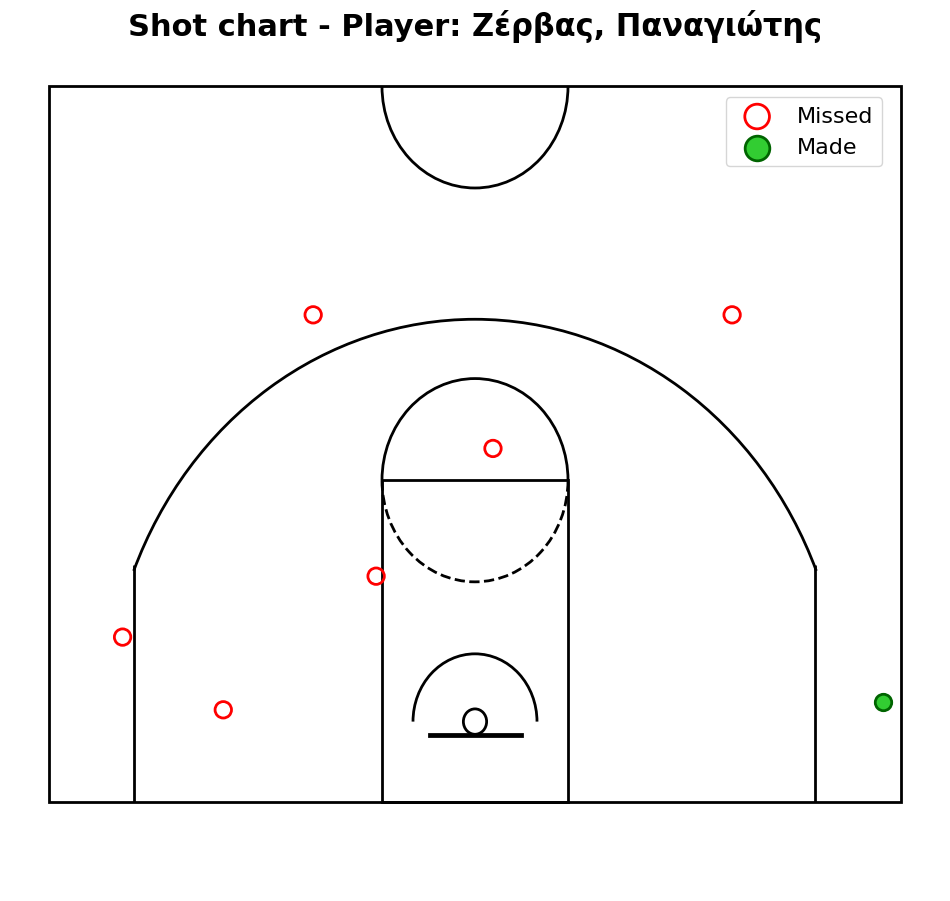

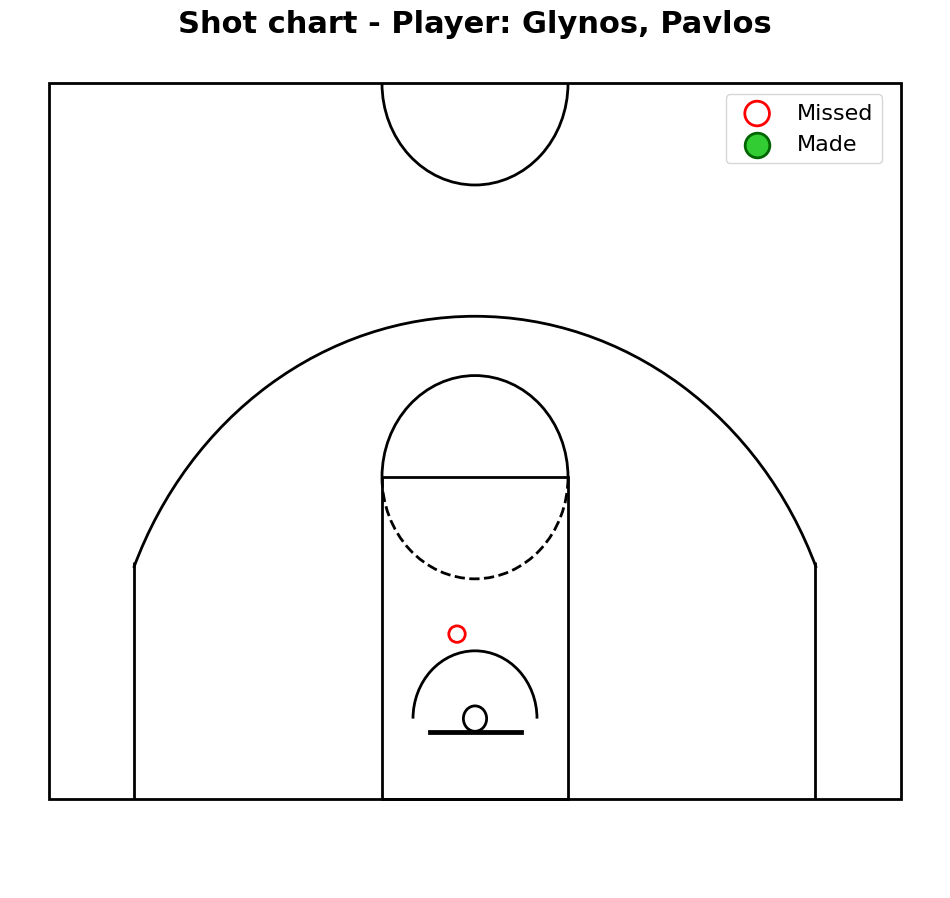

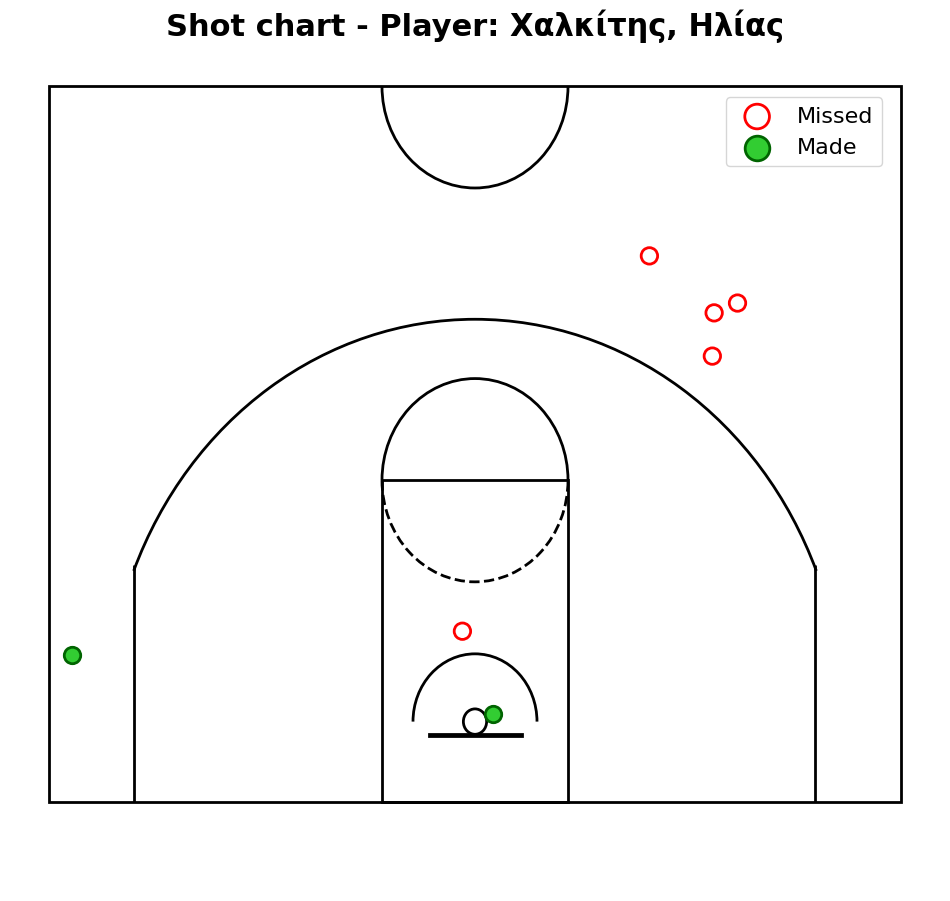

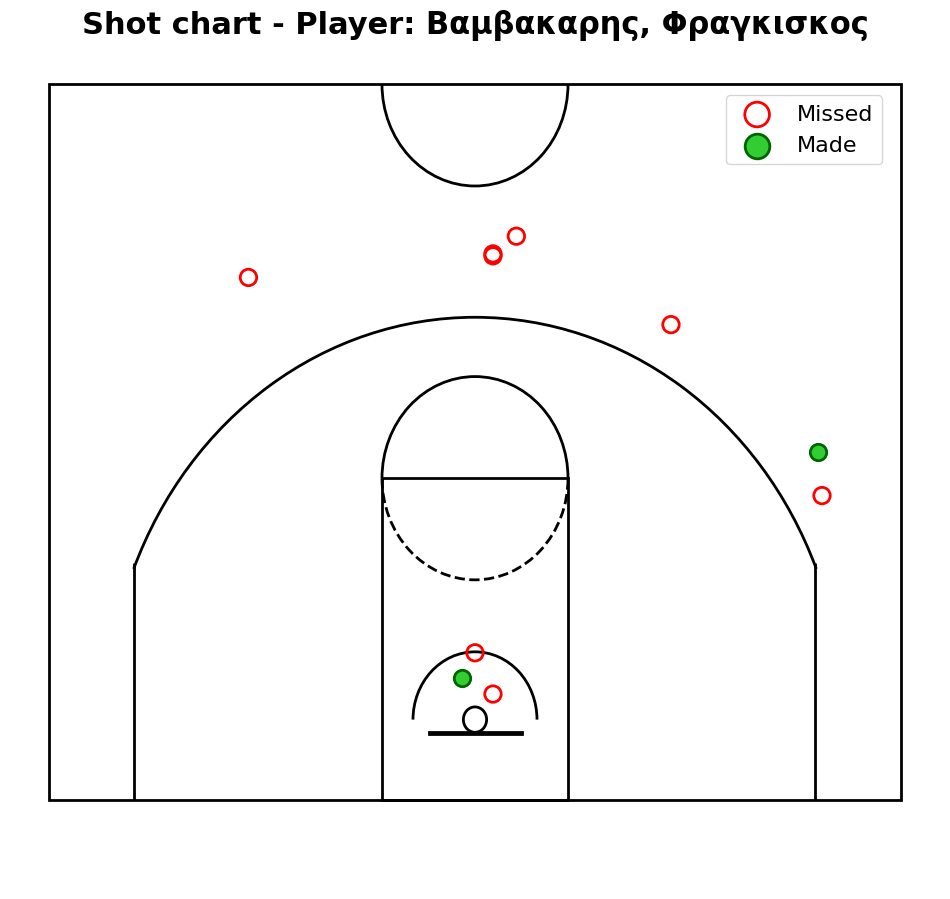

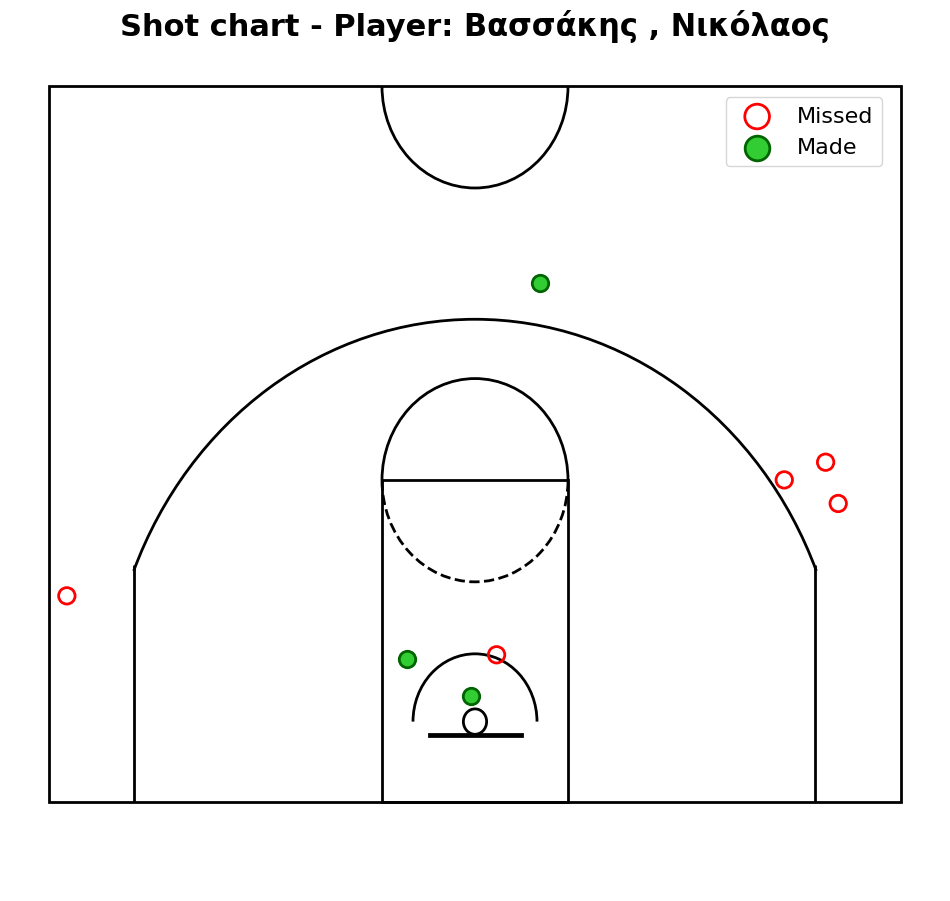

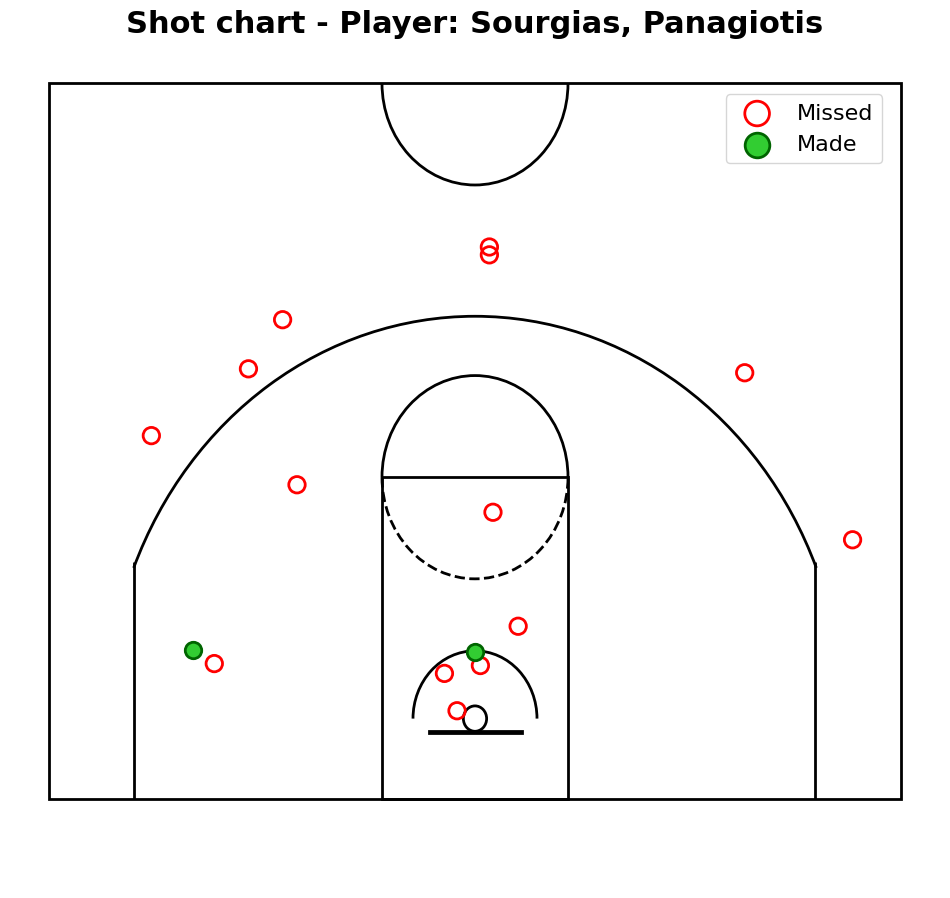

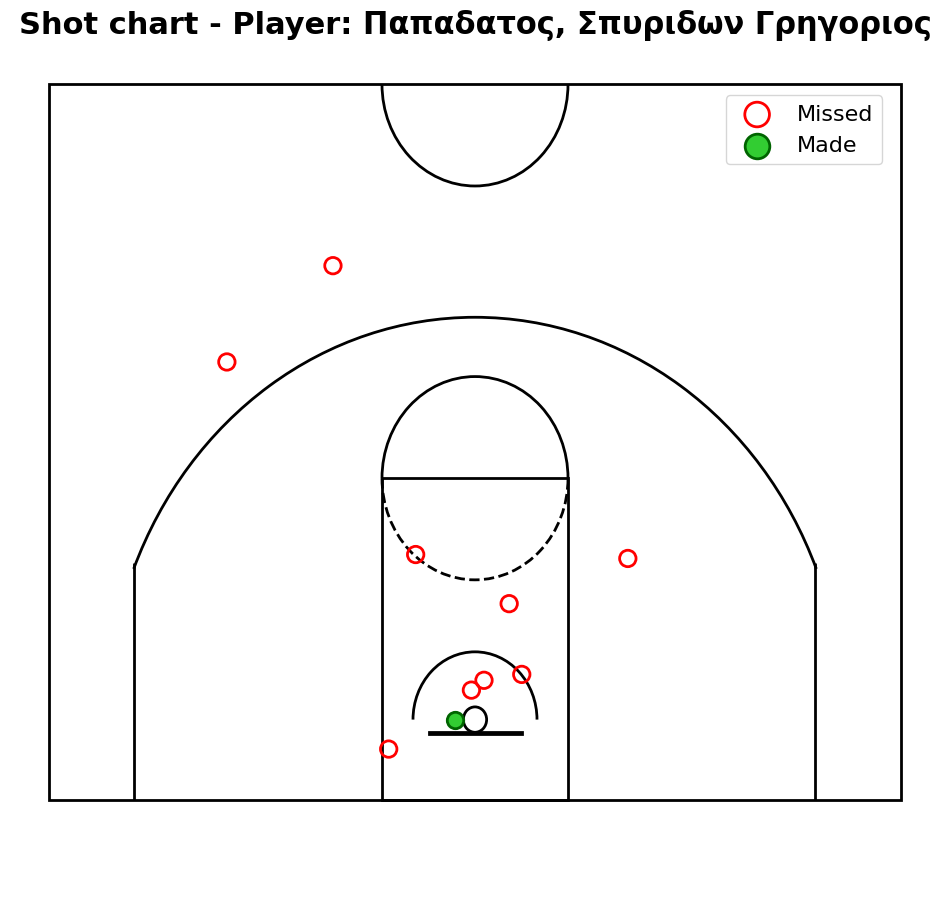

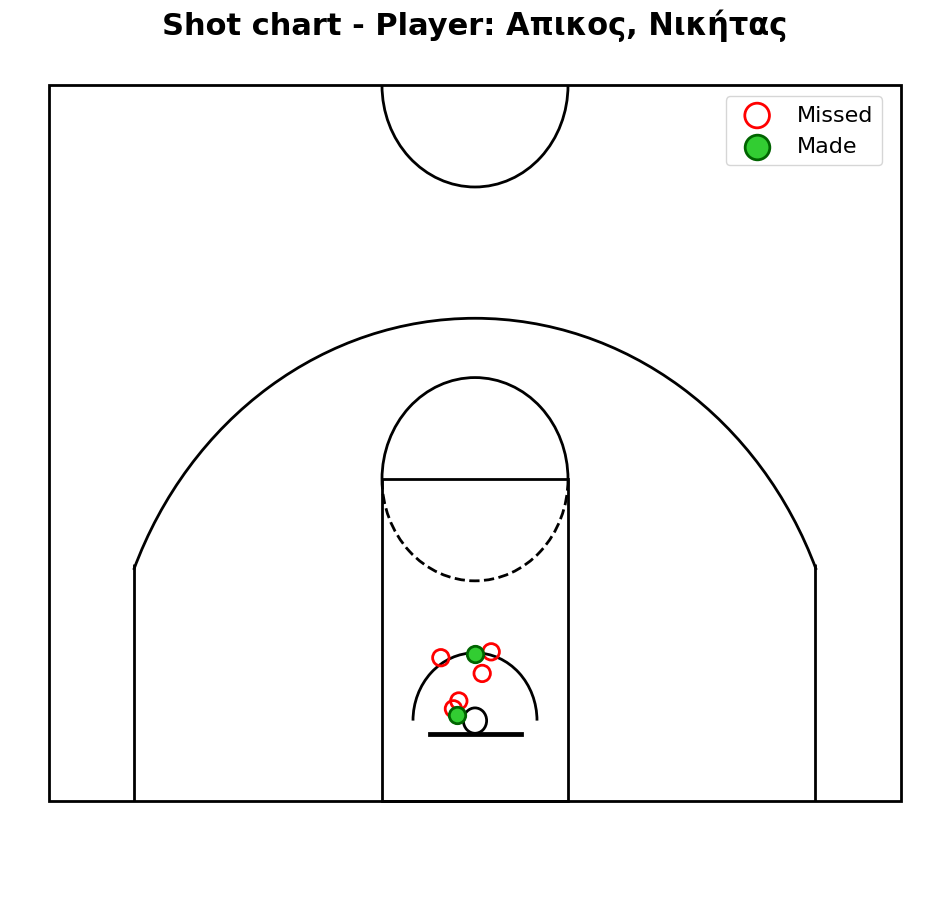

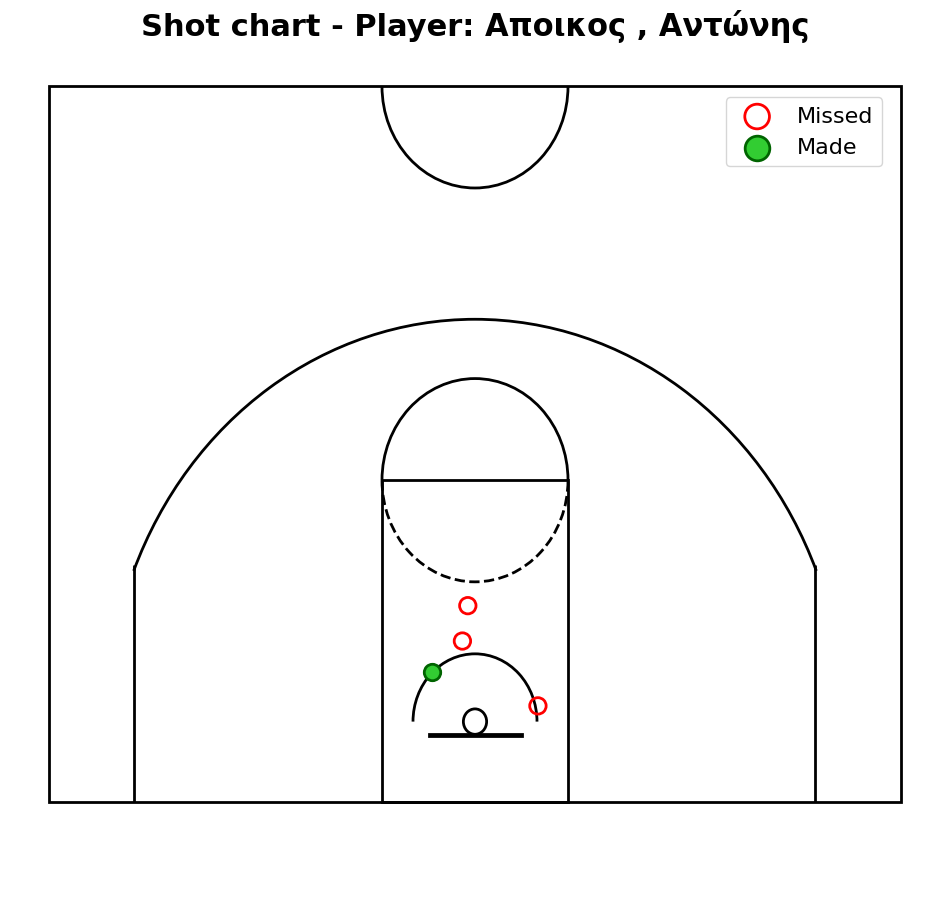

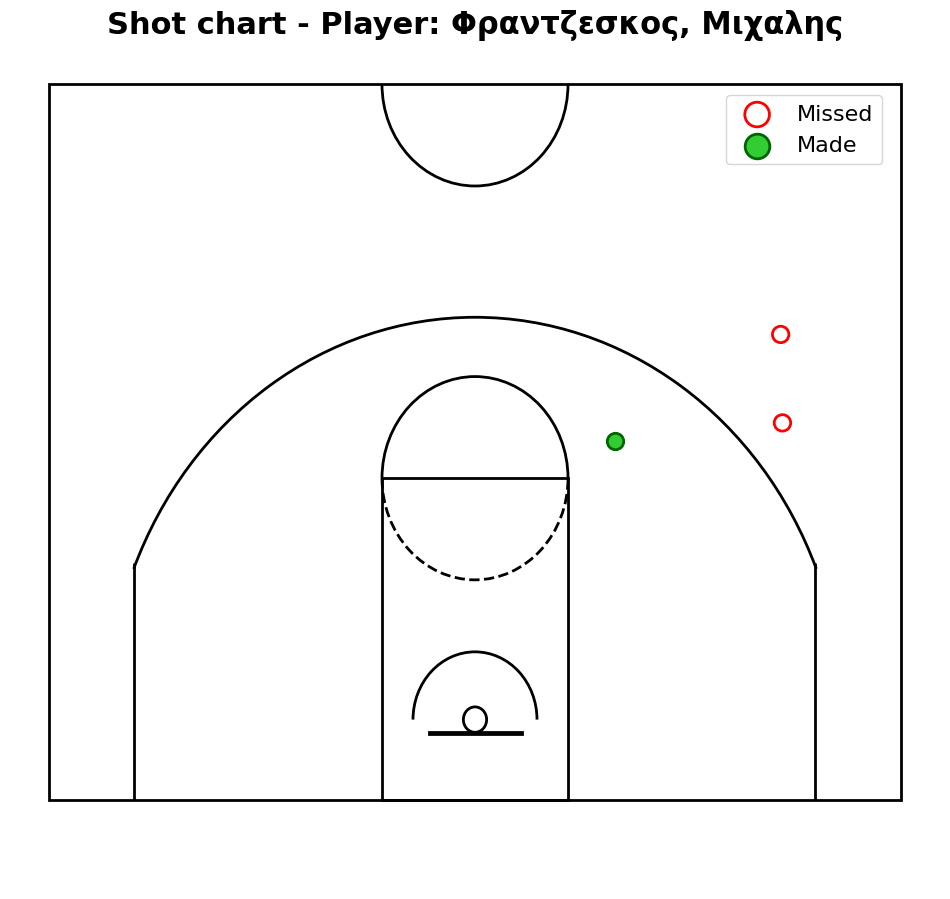

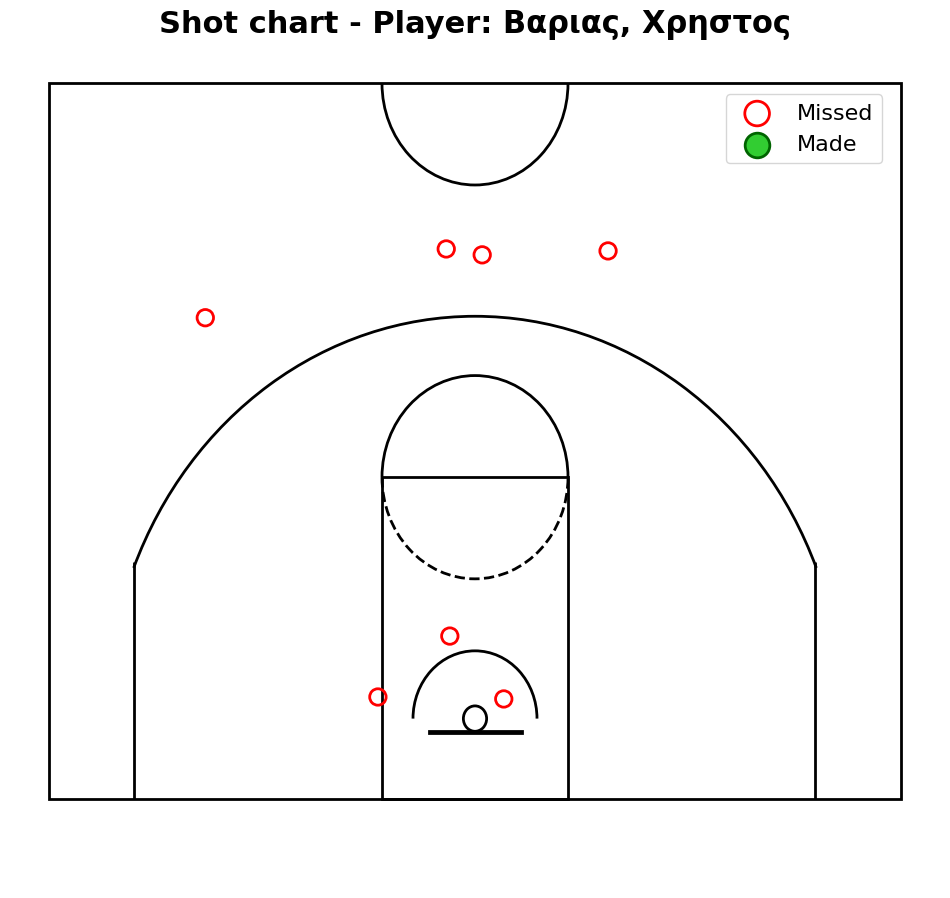

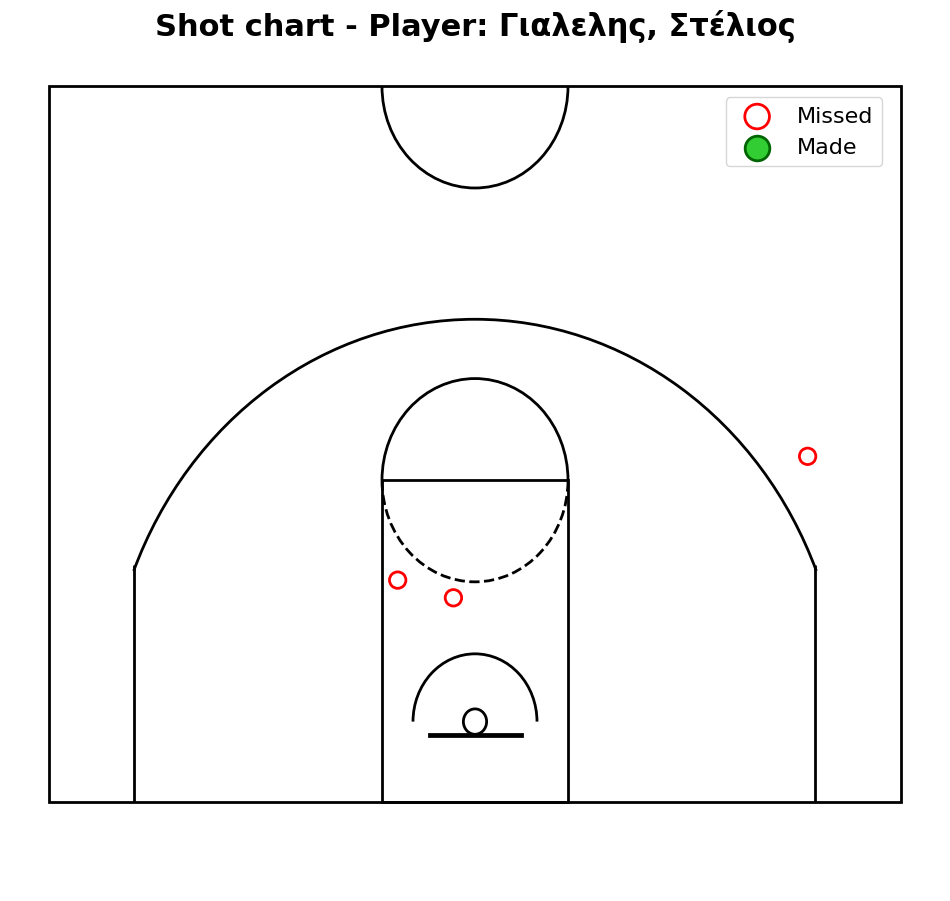

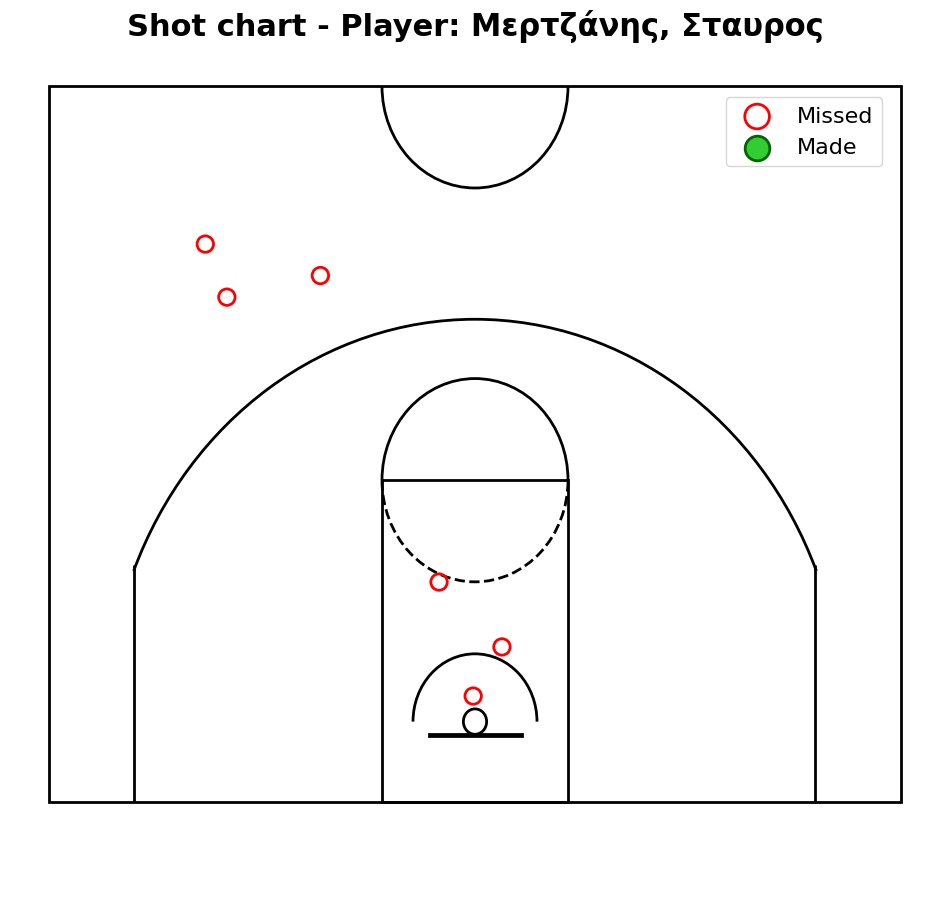

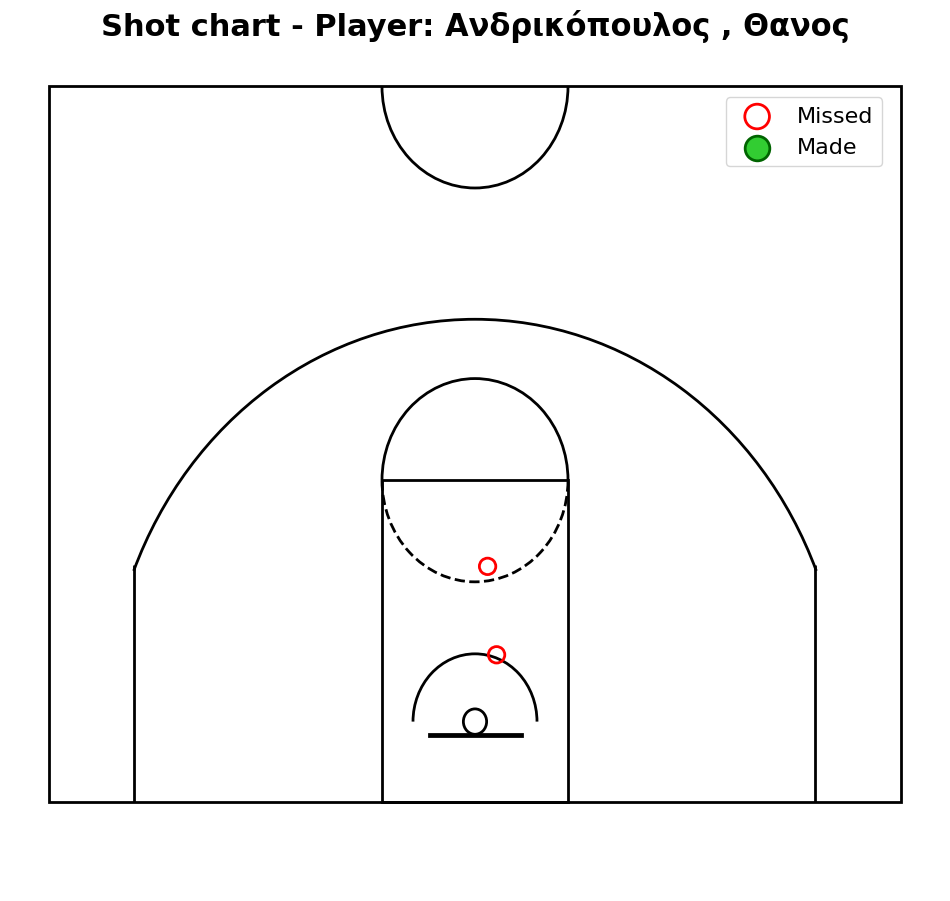

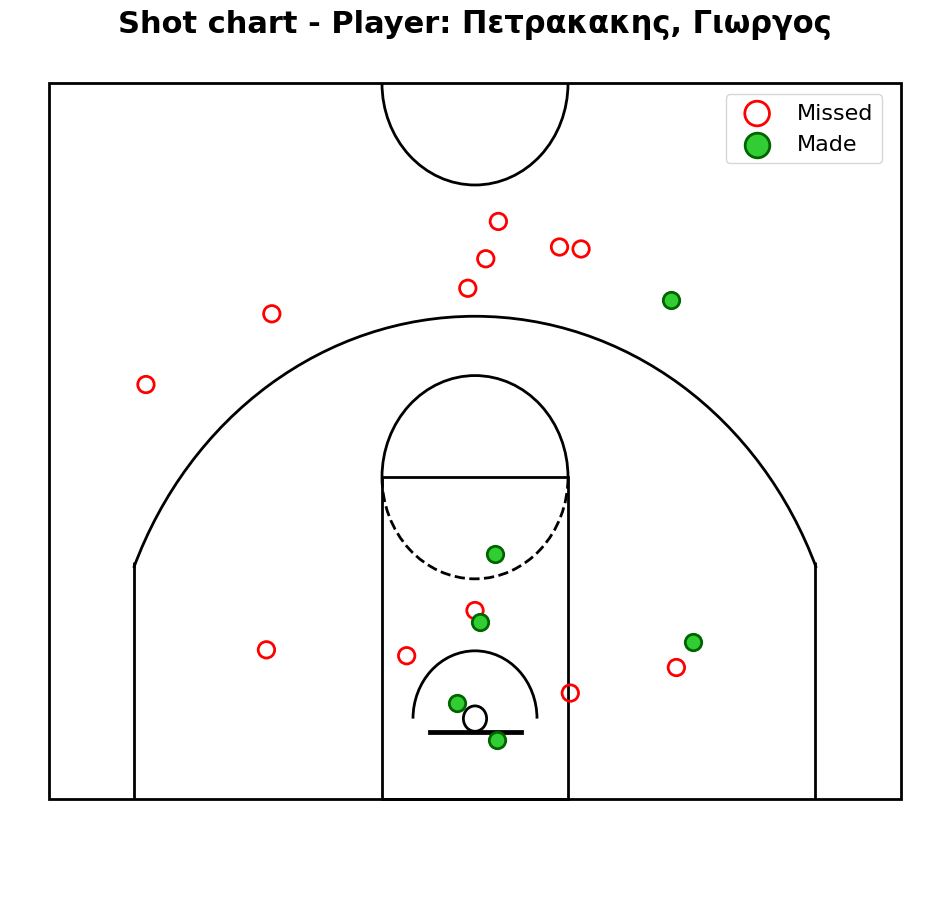

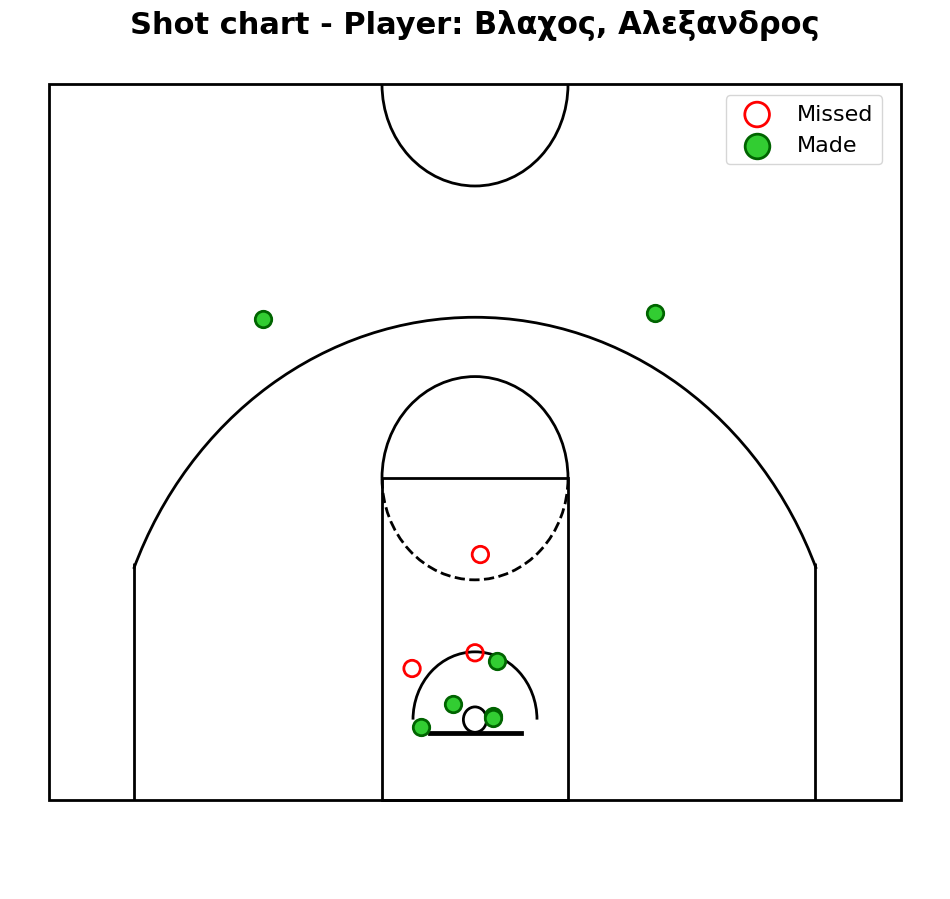

In [109]:
for team, roster in [("away", away_players), ("home", home_players)]:
    for pid, name in roster.items():
        df = get_shots(soup, pid)
        if df.empty:
            continue
        plot_shot_chart(df, name, team)
